In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

# Gradient boosting normal

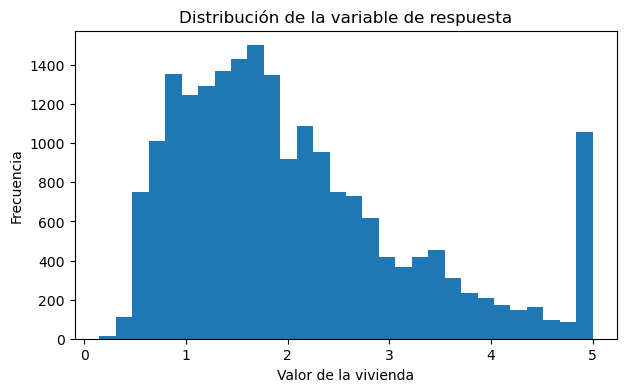

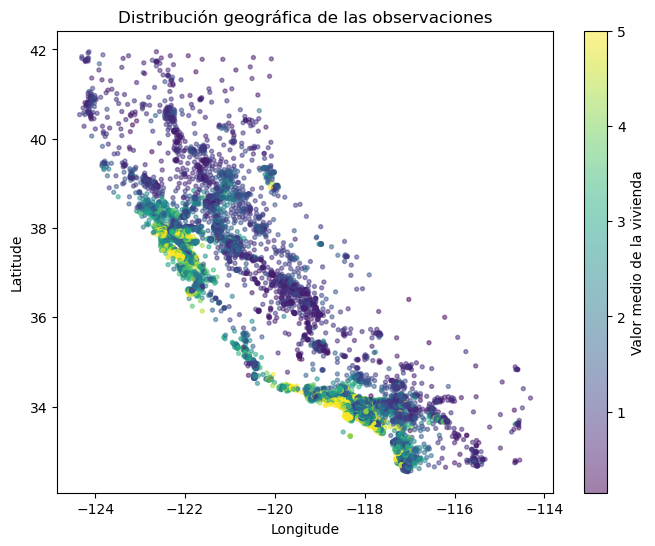

In [2]:
housing  = fetch_california_housing(as_frame = True)
X = housing.data
y = housing.target

plt.figure(figsize = (7,4))
plt.hist(y, bins = 30)
plt.xlabel("Valor de la vivienda")
plt.ylabel("Frecuencia")
plt.title('Distribución de la variable de respuesta')
plt.show()

plt.figure(figsize = (8,6))
plt.scatter(X["Longitude"], X["Latitude"], c= y, s = 8, alpha = 0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución geográfica de las observaciones")
plt.colorbar(label = "Valor medio de la vivienda")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)

dummy = DummyRegressor(strategy = "mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_train)
mae_dummy = mean_absolute_error(y_train, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_train, y_pred_dummy))
print(f"MAE: {mae_dummy}")
print(f"RMSE: {rmse_dummy}")
gbr = GradientBoostingRegressor(
 n_estimators = 100,
learning_rate = 0.1,
    max_depth = 2,
    random_state = 42
)

gbr.fit(X_train, y_train)
y_pred_train = gbr.predict(X_train)
mae_gbr = mean_absolute_error(y_train, y_pred_train)

rmse_gbr = np.sqrt(
    mean_squared_error(y_train, y_pred_train)
)

print(f"MAE GBR:  {mae_gbr:.4f}")
print(f"RMSE GBR: {rmse_gbr:.4f}")

X_train:  (16512, 8)
X_test:  (4128, 8)
MAE: 0.9139114988721792
RMSE: 1.1561912522543263
MAE GBR:  0.3984
RMSE GBR: 0.5629


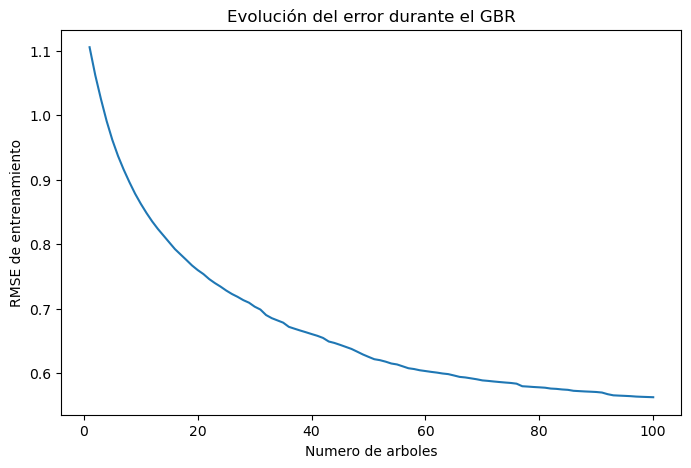

In [4]:
errores_train = []
for y_pred in gbr.staged_predict(X_train):
    rmse = np.sqrt(mean_squared_error(y_train,y_pred))
    errores_train.append(rmse)


plt.figure(figsize = (8,5))
plt.plot(range(1, len(errores_train)+1),errores_train)
plt.xlabel("Numero de arboles")
plt.ylabel("RMSE de entrenamiento")
plt.title("Evolución del error durante el GBR")
plt.show()

In [5]:
learning_rate = [1.0,0.1,0.01]
modelos_lr = {}
for lr in learning_rate:
    modelo = GradientBoostingRegressor(
        n_estimators = 100,
        learning_rate = lr,
        max_depth = 2,
        random_state = 42
    )
    modelo.fit(X_train,y_train)
    modelos_lr[lr] = modelo


resultados_lr = []

for lr, modelo in modelos_lr.items():
    
    pred = modelo.predict(X_train)
    
    rmse = np.sqrt(
        mean_squared_error(y_train, pred)
    )
    
    resultados_lr.append({
        "learning_rate": lr,
        "RMSE_train": rmse
    })

pd.DataFrame(resultados_lr)

,learning_rate,RMSE_train
0,1.00,0.468276
1,0.10,0.562853
2,0.01,0.868894


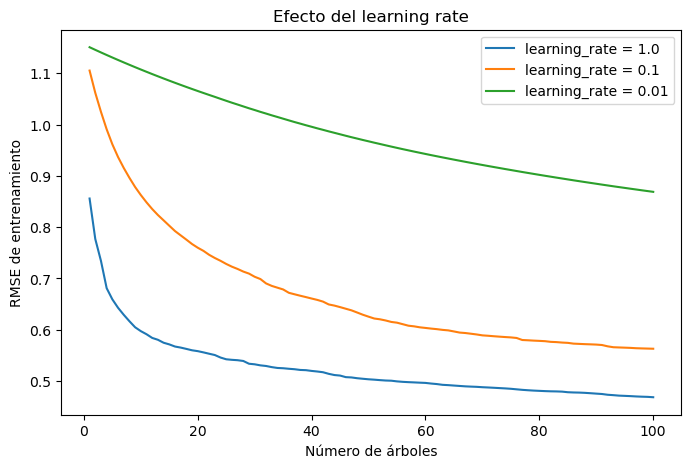

In [6]:
plt.figure(figsize=(8, 5))

for lr, modelo in modelos_lr.items():
    
    errores = []
    
    for pred in modelo.staged_predict(X_train):
        rmse = np.sqrt(
            mean_squared_error(y_train, pred)
        )
        errores.append(rmse)
    
    plt.plot(
        range(1, len(errores) + 1),
        errores,
        label=f"learning_rate = {lr}"
    )

plt.xlabel("Número de árboles")
plt.ylabel("RMSE de entrenamiento")
plt.title("Efecto del learning rate")
plt.legend()
plt.show()

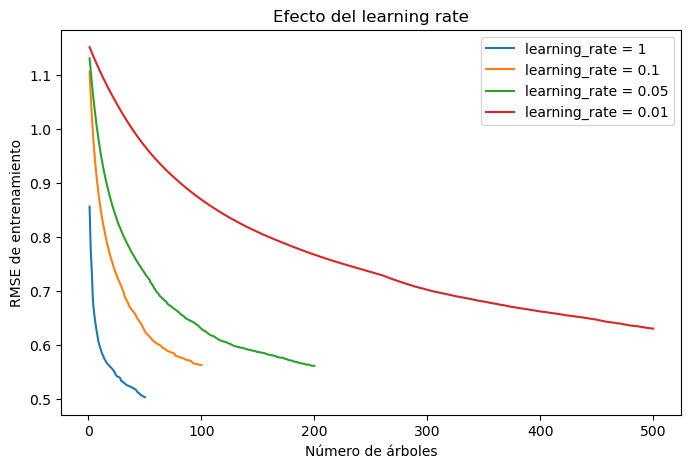

In [7]:
configuraciones = [
    (1,50),
    (0.1,100),
    (0.05,200),
    (0.01,500)
]

modelos_lr = {}

for lr, nesti  in configuraciones:
    modelo = GradientBoostingRegressor(
        n_estimators = nesti,
        learning_rate = lr,
        max_depth = 2,
        random_state = 42
    )
    modelo.fit(X_train,y_train)
    modelos_lr[lr] = modelo


resultados_lr = []

for lr, modelo in modelos_lr.items():
    
    pred = modelo.predict(X_train)
    
    rmse = np.sqrt(
        mean_squared_error(y_train, pred)
    )
    
    resultados_lr.append({
        "learning_rate": lr,
        "RMSE_train": rmse
    })

pd.DataFrame(resultados_lr)

plt.figure(figsize=(8, 5))

for lr, modelo in modelos_lr.items():
    
    errores = []
    
    for pred in modelo.staged_predict(X_train):
        rmse = np.sqrt(
            mean_squared_error(y_train, pred)
        )
        errores.append(rmse)
    
    plt.plot(
        range(1, len(errores) + 1),
        errores,
        label=f"learning_rate = {lr}"
    )

plt.xlabel("Número de árboles")
plt.ylabel("RMSE de entrenamiento")
plt.title("Efecto del learning rate")
plt.legend()
plt.show()

In [8]:
modelos_lr = {}
profundidades = range(1,5)
for depth  in profundidades:
    modelo = GradientBoostingRegressor(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = depth,
        random_state = 42
    )
    modelo.fit(X_train,y_train)
    modelos_lr[depth] = modelo


resultados_lr = []

for lr, modelo in modelos_lr.items():
    
    pred = modelo.predict(X_train)
    
    rmse = np.sqrt(
        mean_squared_error(y_train, pred)
    )
    
    resultados_lr.append({
        "depth": lr,
        "RMSE_train": rmse
    })
resultados = pd.DataFrame(resultados_lr)

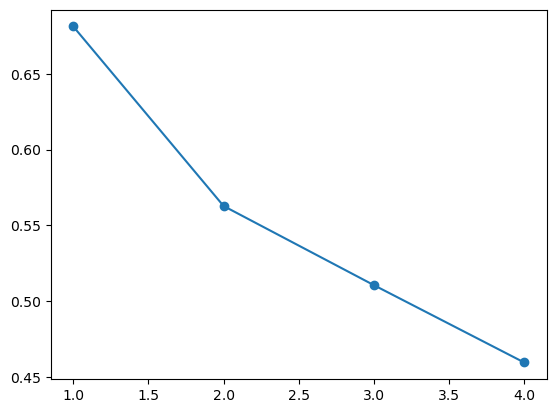

In [9]:
#Grafica
plt.plot(resultados["depth"],resultados["RMSE_train"], marker = 'o')

In [10]:
x_train_gb, x_val, y_train_gb, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)
gbr_long = GradientBoostingRegressor(
    n_estimators = 500,
    learning_rate = 0.1,
    max_depth = 2,
    random_state=42
)

gbr_long.fit(x_train_gb, y_train_gb)

rmse_train = []
rmse_val = []

for pred_train, pred_val in zip(gbr_long.staged_predict(x_train_gb), gbr_long.staged_predict(x_val)):
    rmse_train.append(np.sqrt(mean_squared_error(y_train_gb, pred_train)))
    rmse_val.append(np.sqrt(mean_squared_error(y_val, pred_val)))


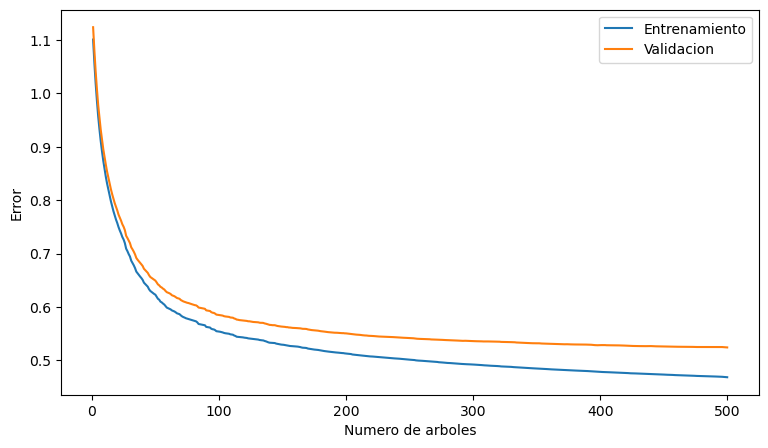

In [11]:
plt.figure(figsize = (9,5))
plt.plot(range(1,len(rmse_train)+1),rmse_train, label = "Entrenamiento"
        )
plt.plot(range(1,len(rmse_val)+1),rmse_val, label = "Validacion"
        )
plt.xlabel("Numero de arboles")
plt.ylabel("Error")
plt.legend()
plt.show()

In [12]:
gbr_auto = GradientBoostingRegressor(
    n_estimators = 1000,
    learning_rate = 0.1,
    max_depth = 2,
    validation_fraction = 0.1,
    n_iter_no_change = 10,
    tol = 1e-4,
    random_state = 42
)
gbr_auto.fit(X_train,y_train)

gbr_auto.n_estimators_

354

In [13]:
gbr_stochastic = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

gbr_stochastic.fit(x_train_gb, y_train_gb)

GradientBoostingRegressor(max_depth=2, n_estimators=200, random_state=42,
                          subsample=0.8)

In [14]:
from xgboost  import XGBRegressor

In [15]:
xgb = XGBRegressor(
    n_stimators = 200,
    learnig_rate = 0.1,
    max_depth = 2,
    objetive = "reg:squarederror",
    random_state = 42,
    n_jobs = -1
)
xgb.fit(x_train_gb,y_train_gb)

pred_xgb = xgb.predict(x_val)
mae_xgb = mean_absolute_error(y_val, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_xgb))
print(mae_xgb)
print(rmse_xgb)

0.37926482800014366
0.5434724368605446


/home/gdiek/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:06:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "learnig_rate", "n_stimators", "objetive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
gbr_compare = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 2,
    random_state = 42
)
gbr_compare.fit(x_train_gb, y_train_gb)
pred_gbr = gbr_compare.predict(x_val)

pred_gbr = gbr_compare.predict(x_val)
mae_gbr = mean_absolute_error(y_val, pred_gbr)
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_gbr))
print(mae_gbr)
print(rmse_gbr)

0.3843280005734157
0.5628534141188141


In [17]:
xgb_reg = XGBRegressor(
    n_estimators = 300,
    learnig_rate = 0.05,
    max_depth = 2,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_alpha = 0.1,
    reg_lambda = 1.0,
    objetive = "reg:squarederror",
    random_state = 42,
    n_jobs = -1
)

xgb_reg.fit(x_train_gb, y_train_gb)

pred_xgb_reg = xgb_reg.predict(x_val)
rmse_xgb_reg = np.sqrt(mean_squared_error(y_val,pred_xgb_reg))
rmse_xgb_reg

/home/gdiek/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:06:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "learnig_rate", "objetive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


np.float64(0.5156586386604926)

# Ejercicios

## 9.18.1 Parte 1
Entrena los cuatro modelos utilizando X_train_gb y y_train_gb.

Completa el siguiente código.

Código
configuraciones = [
    # ("A", ..., ..., ...),
    # ("B", ..., ..., ...),
    # ("C", ..., ..., ...),
    # ("D", ..., ..., ...)
]

Para cada configuración:

entrena un GradientBoostingRegressor;
calcula el RMSE de entrenamiento;
calcula el RMSE de validación;
guarda los resultados en un DataFrame.


In [18]:
data = {
    "Modelo": ["A",'B','C','D'],
    'learning_rate': [0.1,0.05,0.01,0.1],
    'n_estimators': [100,200,500,100],
    'max_depth': [2,2,2,4]
}

df = pd.DataFrame(data)
rmse_train = []
rmse_val = []

for model in df["Modelo"]:
    gbr_auto = GradientBoostingRegressor(
    n_estimators = df.loc[df["Modelo"]==model,'n_estimators'].values[0],
    learning_rate = df.loc[df["Modelo"]==model,'learning_rate'].values[0],
    max_depth =df.loc[df["Modelo"]==model,'max_depth'].values[0],
    )

    gbr_auto.fit(x_train_gb,y_train_gb)
    pred_train = gbr_auto.predict(x_train_gb)
    pred_val = gbr_auto.predict(x_val)
    rmsetrain = np.sqrt(mean_squared_error(y_train_gb,pred_train))
    rmseval =np.sqrt(mean_squared_error(y_val,pred_val))
    
    rmse_train.append(rmsetrain)
    rmse_val.append(rmseval)

df["RMSE train"]=rmse_train
df["RMSE val"]=rmse_val
df


,Modelo,learning_rate,n_estimators,max_depth,RMSE train,RMSE val
0,A,0.10,100,2,0.554203,0.585258
1,B,0.05,200,2,0.559410,0.589458
2,C,0.01,500,2,0.625263,0.652214
3,D,0.10,100,4,0.450161,0.520065


## 9.18.2 Parte 2
Responde brevemente:

¿Cuál configuración obtiene el menor error de entrenamiento?

RESPUESTA: El modelo D

¿Coincide con la configuración que obtiene el menor error de validación?

RESPUESTA: Si

Compara A, B y C. ¿Qué observas sobre la relación entre learning_rate y n_estimators?

RESPUESTA: Que a menor tasa de aprendizaje mayor numeor de estimadores

¿Qué efecto observas al aumentar max_depth de 2 a 4?

RESPUESTA: Que tanto el error de entrenamiento y de validación disminuye

¿Por qué no deberíamos utilizar X_test para decidir cuál de estas cuatro configuraciones conservar?

RESPUESTA: Porque es un se utiliza un error de ajuste de entrenamiento estamos decidiendo cual es mejor ajuste con los datos que usamos para entrenar el modelo en lugar de utilizar los de validación.